<a href="https://colab.research.google.com/github/yaeliavni/AI/blob/main/LAPD_EDAipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **EDA**

Creating offline LA Crime Visualizations...
Loading data...
Raw data shape: (974477, 15)
Cleaned data shape: (963147, 2)
Creating heatmap with 50,000 crime locations...


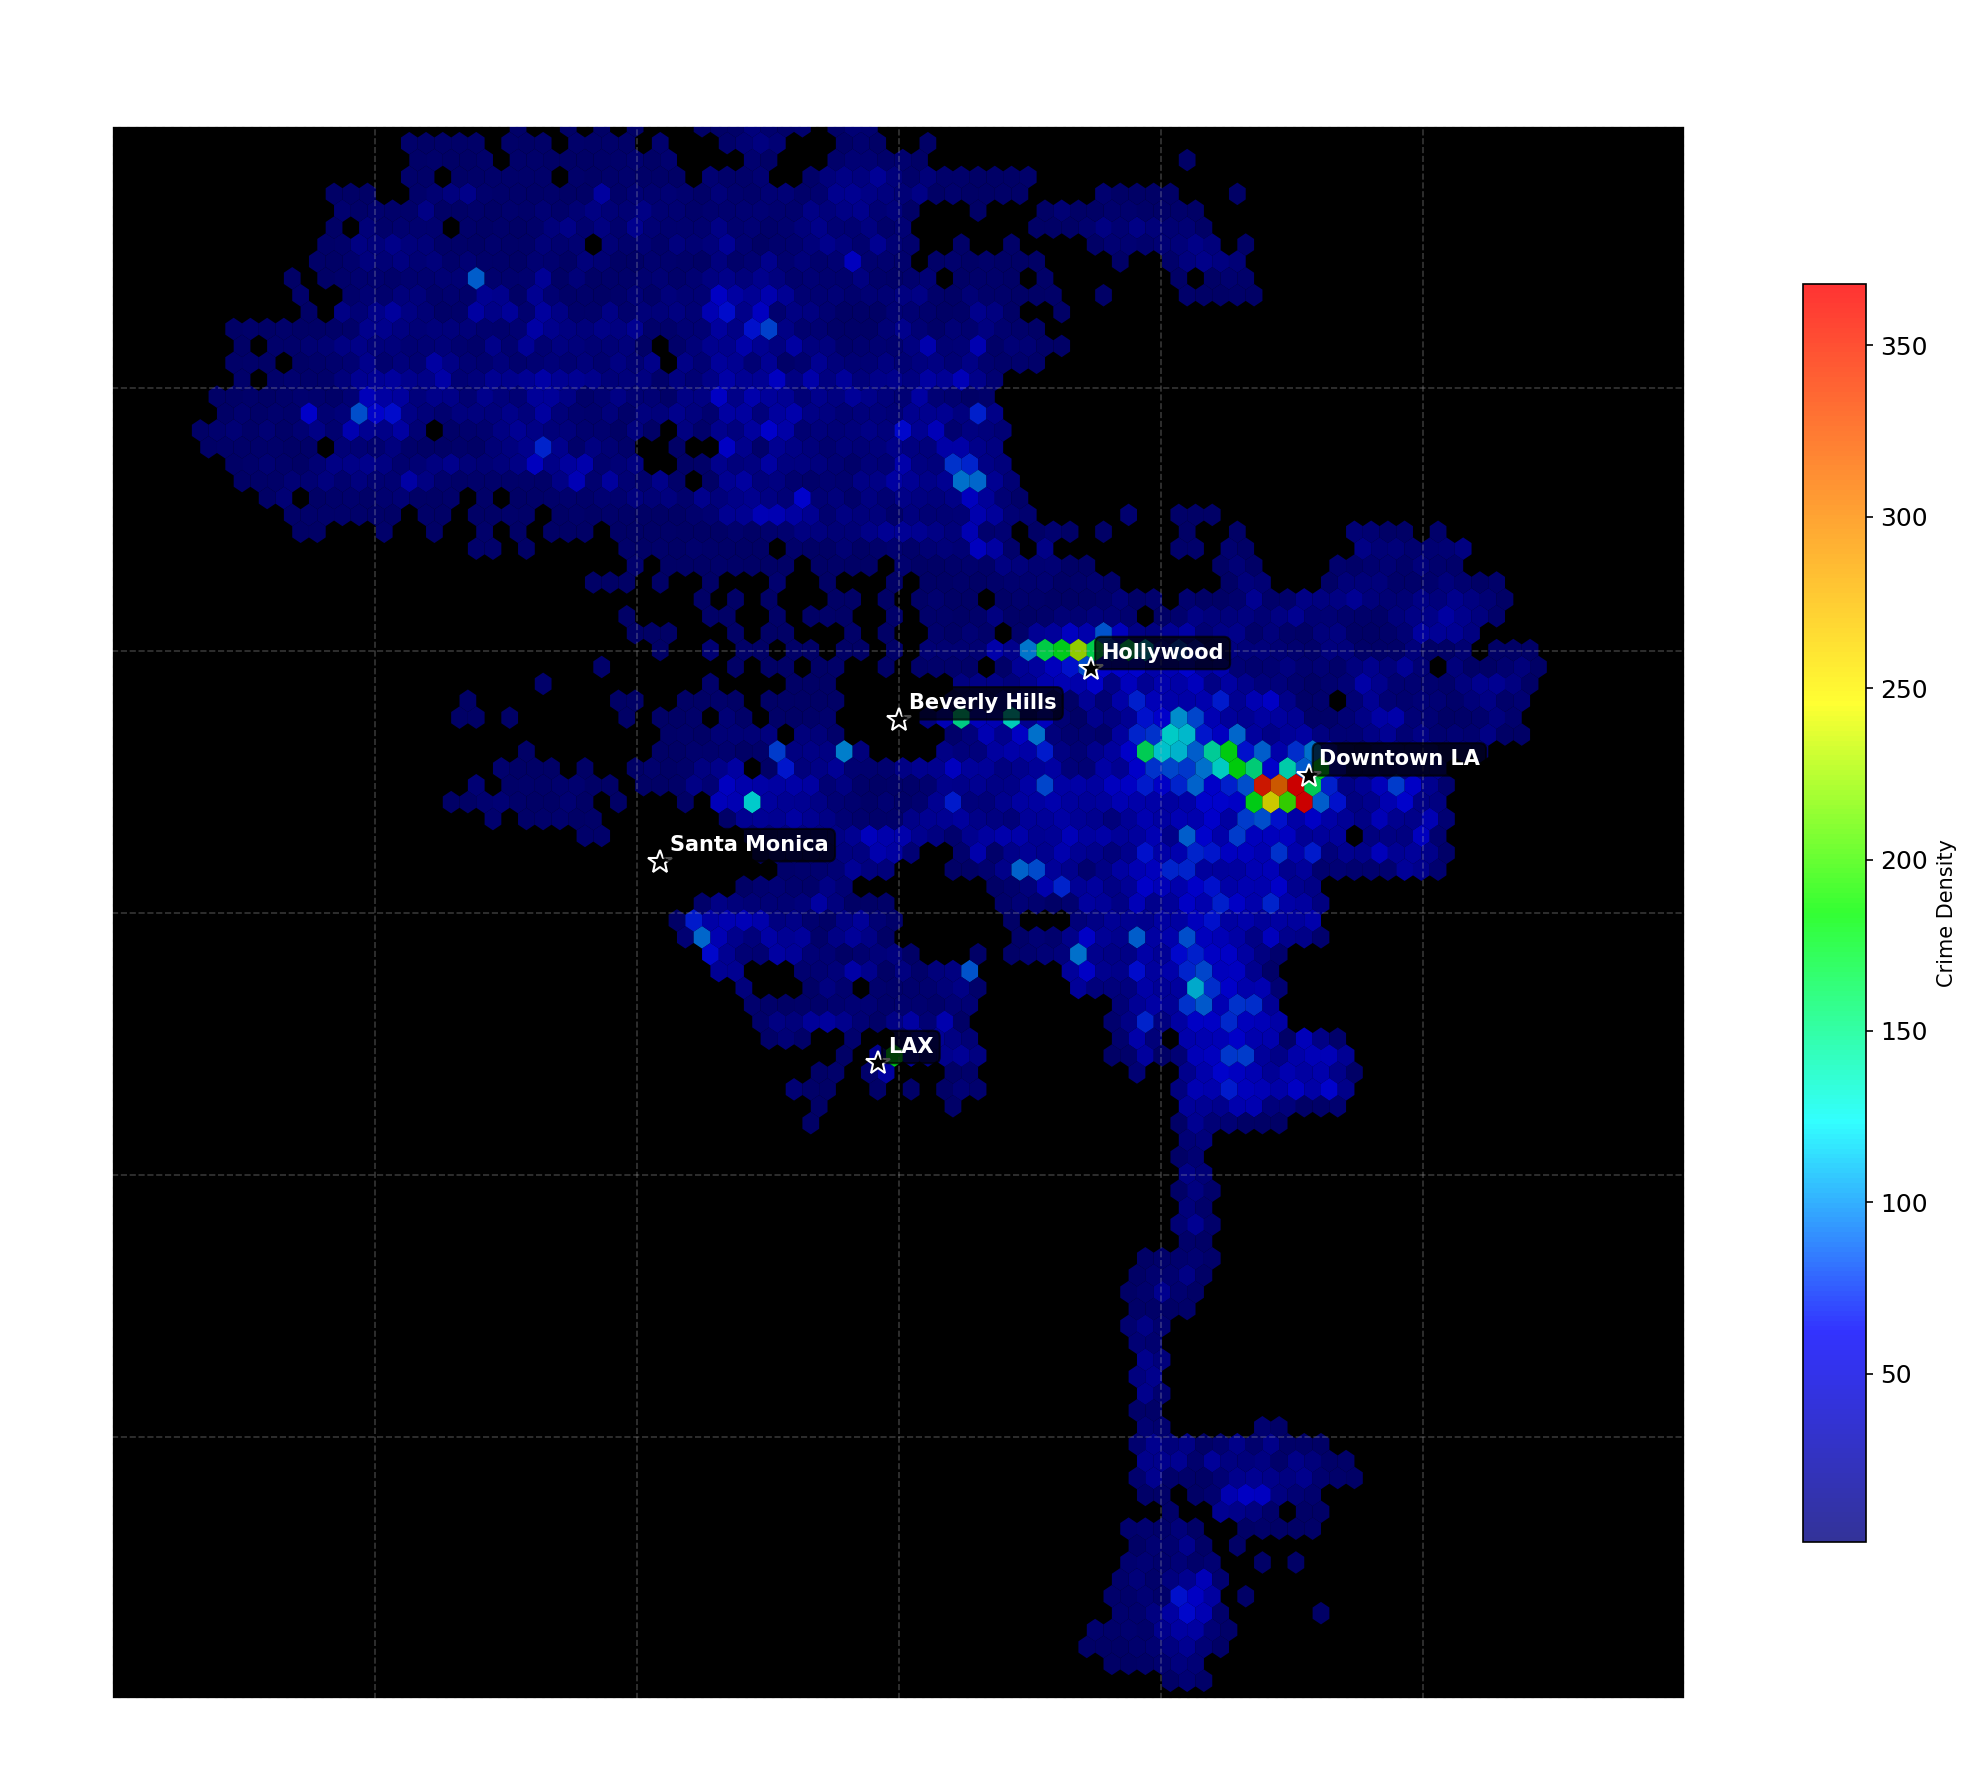

Crime heatmap saved to: /content/la_crime_heatmap.png
Creating scatter map with 20,000 points...


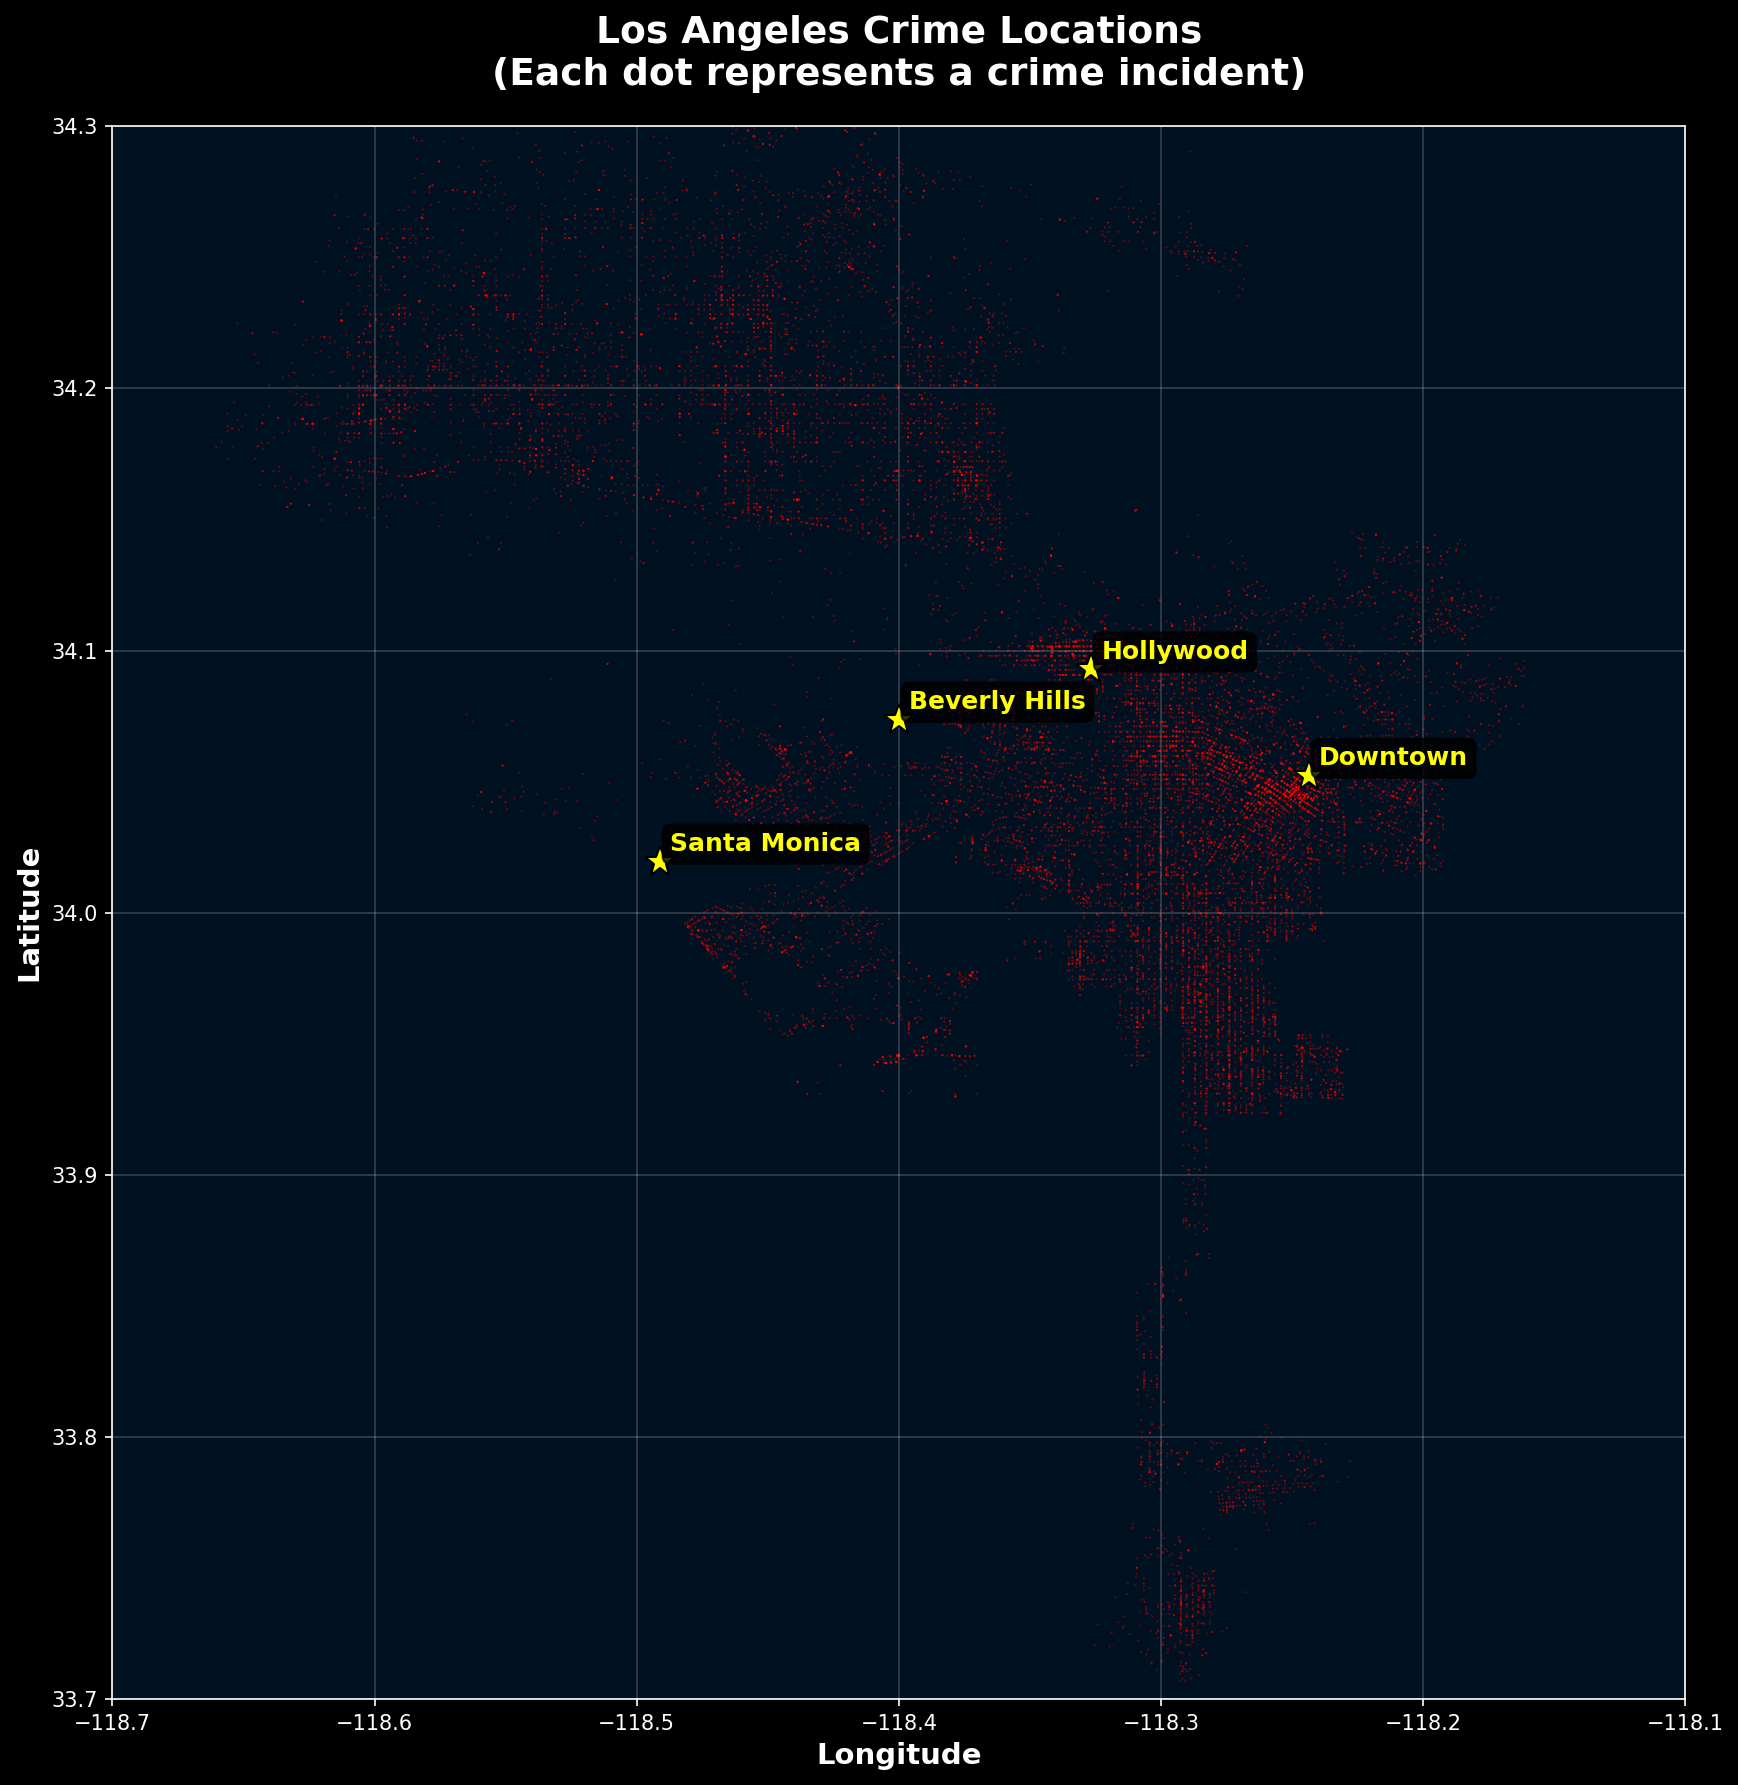

Scatter map saved to: /content/la_crime_scatter.png
Creating neighborhood analysis...


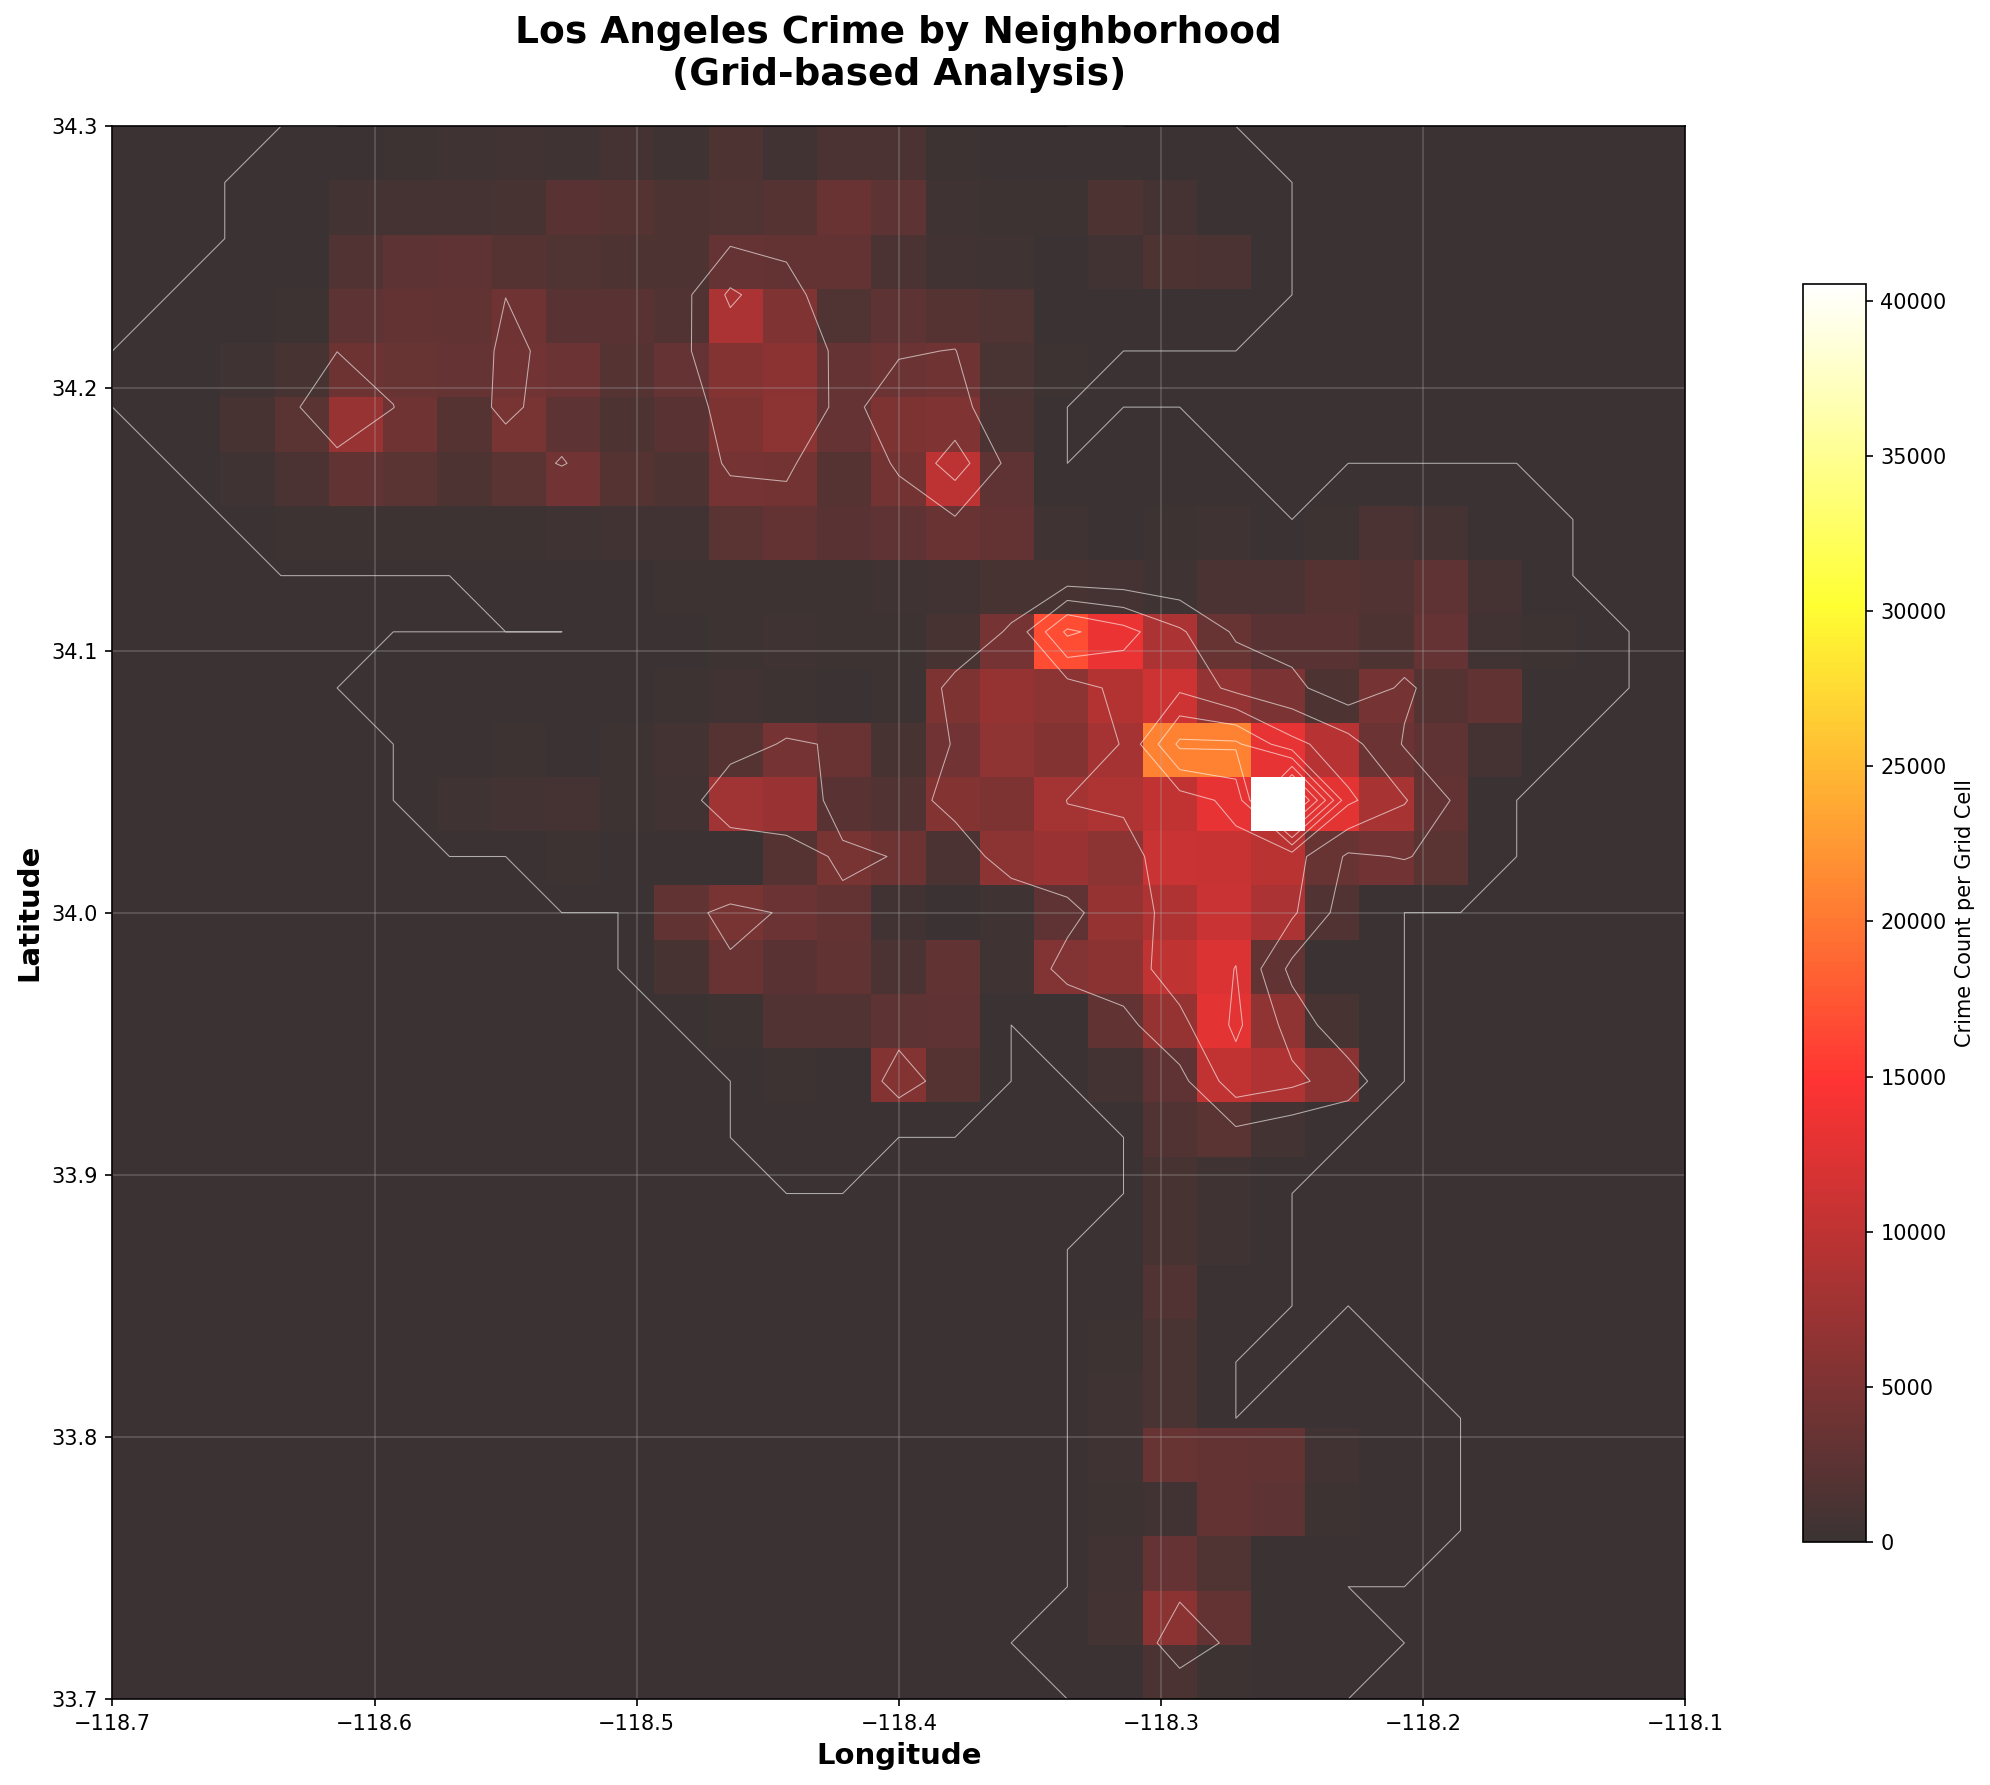

Neighborhood analysis saved to: /content/la_crime_neighborhoods.png

All visualizations created successfully!
Files saved in: /content

Crime Data Summary:
Total crimes plotted: 963,147
Latitude range: 33.706 to 34.300
Longitude range: -118.668 to -118.155


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

# Configuration
RAW_PATH = "/content/Crime_Data_from_2020_to_Present.csv.zip"
OUTPUT_DIR = "/content"
SAMPLE_SIZE = 50000

def clean_and_filter_data(df):
    """Quick data cleaning focused on coordinates"""
    # Replace missing value sentinels
    missing_vals = ["", " ", "NA", "N/A", "None", "null", "?", "-", "0"]
    df = df.replace(missing_vals, np.nan)

    # Focus on essential columns for mapping
    essential_cols = ['LAT', 'LON', 'DATE OCC', 'TIME OCC', 'Crm Cd Desc']
    available_cols = [col for col in essential_cols if col in df.columns]

    if 'LAT' not in df.columns or 'LON' not in df.columns:
        print("Error: LAT/LON columns not found")
        return None

    df_clean = df[available_cols].copy()

    # Convert coordinates to numeric
    df_clean['LAT'] = pd.to_numeric(df_clean['LAT'], errors='coerce')
    df_clean['LON'] = pd.to_numeric(df_clean['LON'], errors='coerce')

    # Filter to LA area (removes 0,0 and outliers)
    la_bounds = {
        'lat_min': 33.7, 'lat_max': 34.3,
        'lon_min': -118.7, 'lon_max': -118.1
    }

    df_clean = df_clean[
        (df_clean['LAT'].between(la_bounds['lat_min'], la_bounds['lat_max'])) &
        (df_clean['LON'].between(la_bounds['lon_min'], la_bounds['lon_max']))
    ].dropna(subset=['LAT', 'LON'])

    return df_clean

def create_crime_heatmap(df, output_path):
    """Create a beautiful crime density heatmap using matplotlib"""

    # Sample data if too large
    if len(df) > SAMPLE_SIZE:
        df_sample = df.sample(n=SAMPLE_SIZE, random_state=42)
    else:
        df_sample = df

    print(f"Creating heatmap with {len(df_sample):,} crime locations...")

    # Create figure with high DPI for crisp output
    plt.figure(figsize=(16, 12), dpi=150)

    # Create custom colormap (Google Maps style)
    colors = ['#000080', '#0000FF', '#00FFFF', '#00FF00', '#FFFF00', '#FF8000', '#FF0000']
    n_bins = 256
    cmap = LinearSegmentedColormap.from_list('crime_heat', colors, N=n_bins)

    # Create 2D histogram (heatmap)
    plt.hexbin(df_sample['LON'], df_sample['LAT'],
               gridsize=80,
               cmap=cmap,
               alpha=0.8,
               mincnt=1,
               edgecolors='none')

    # Add colorbar
    cbar = plt.colorbar(label='Crime Density', shrink=0.8)
    cbar.ax.tick_params(labelsize=12)

    # Add major LA landmarks as reference points
    landmarks = {
        'Downtown LA': (-118.2437, 34.0522),
        'Hollywood': (-118.3267, 34.0928),
        'Santa Monica': (-118.4912, 34.0195),
        'Beverly Hills': (-118.4001, 34.0736),
        'LAX': (-118.4081, 33.9425)
    }

    for name, (lon, lat) in landmarks.items():
        plt.plot(lon, lat, 'k*', markersize=12, markeredgecolor='white', markeredgewidth=1)
        plt.annotate(name, (lon, lat), xytext=(5, 5), textcoords='offset points',
                    fontsize=10, fontweight='bold', color='white',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))

    # Styling
    plt.xlabel('Longitude', fontsize=14, fontweight='bold')
    plt.ylabel('Latitude', fontsize=14, fontweight='bold')
    plt.title('Los Angeles Crime Density Map\n(Higher intensity = More crimes)',
              fontsize=18, fontweight='bold', pad=20)

    # Set aspect ratio and limits
    plt.gca().set_aspect('equal', adjustable='box')
    plt.xlim(-118.7, -118.1)
    plt.ylim(33.7, 34.3)

    # Add grid
    plt.grid(True, alpha=0.3, linestyle='--')

    # Style the plot
    plt.gca().set_facecolor('black')
    plt.gca().spines['bottom'].set_color('white')
    plt.gca().spines['top'].set_color('white')
    plt.gca().spines['right'].set_color('white')
    plt.gca().spines['left'].set_color('white')
    plt.gca().tick_params(colors='white')
    plt.gca().xaxis.label.set_color('white')
    plt.gca().yaxis.label.set_color('white')
    plt.gca().title.set_color('white')

    plt.tight_layout()
    plt.savefig(output_path, facecolor='black', edgecolor='none', bbox_inches='tight')
    plt.show()
    print(f"Crime heatmap saved to: {output_path}")

def create_scatter_density_map(df, output_path):
    """Create a scatter plot with density-based coloring"""

    if len(df) > 20000:  # Limit for performance
        df_sample = df.sample(n=20000, random_state=42)
    else:
        df_sample = df

    print(f"Creating scatter map with {len(df_sample):,} points...")

    plt.figure(figsize=(16, 12), dpi=150)

    # Create scatter plot with density-based colors
    plt.scatter(df_sample['LON'], df_sample['LAT'],
               c='red', alpha=0.4, s=1, edgecolors='none')

    # Add landmarks
    landmarks = {
        'Downtown': (-118.2437, 34.0522),
        'Hollywood': (-118.3267, 34.0928),
        'Santa Monica': (-118.4912, 34.0195),
        'Beverly Hills': (-118.4001, 34.0736)
    }

    for name, (lon, lat) in landmarks.items():
        plt.plot(lon, lat, 'yellow', marker='*', markersize=15,
                markeredgecolor='black', markeredgewidth=1)
        plt.annotate(name, (lon, lat), xytext=(5, 5), textcoords='offset points',
                    fontsize=12, fontweight='bold', color='yellow',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.8))

    plt.xlabel('Longitude', fontsize=14, fontweight='bold')
    plt.ylabel('Latitude', fontsize=14, fontweight='bold')
    plt.title('Los Angeles Crime Locations\n(Each dot represents a crime incident)',
              fontsize=18, fontweight='bold', pad=20)

    plt.gca().set_aspect('equal', adjustable='box')
    plt.xlim(-118.7, -118.1)
    plt.ylim(33.7, 34.3)
    plt.grid(True, alpha=0.3)

    # Dark theme
    plt.gca().set_facecolor('#001122')
    plt.gcf().patch.set_facecolor('black')
    plt.gca().spines['bottom'].set_color('white')
    plt.gca().spines['top'].set_color('white')
    plt.gca().spines['right'].set_color('white')
    plt.gca().spines['left'].set_color('white')
    plt.gca().tick_params(colors='white')
    plt.gca().xaxis.label.set_color('white')
    plt.gca().yaxis.label.set_color('white')
    plt.gca().title.set_color('white')

    plt.tight_layout()
    plt.savefig(output_path, facecolor='black', bbox_inches='tight')
    plt.show()
    print(f"Scatter map saved to: {output_path}")

def create_neighborhood_analysis(df, output_path):
    """Create a grid-based neighborhood crime analysis"""

    print("Creating neighborhood analysis...")

    # Create a grid over LA
    lon_bins = np.linspace(-118.7, -118.1, 30)
    lat_bins = np.linspace(33.7, 34.3, 30)

    # Count crimes in each grid cell
    H, xedges, yedges = np.histogram2d(df['LON'], df['LAT'], bins=[lon_bins, lat_bins])

    plt.figure(figsize=(16, 12), dpi=150)

    # Create the heatmap
    im = plt.imshow(H.T, origin='lower',
                   extent=[lon_bins[0], lon_bins[-1], lat_bins[0], lat_bins[-1]],
                   cmap='hot', aspect='equal', alpha=0.8)

    plt.colorbar(im, label='Crime Count per Grid Cell', shrink=0.8)

    # Add contour lines
    plt.contour(H.T, levels=10, colors='white', alpha=0.6, linewidths=0.5,
               extent=[lon_bins[0], lon_bins[-1], lat_bins[0], lat_bins[-1]])

    plt.xlabel('Longitude', fontsize=14, fontweight='bold')
    plt.ylabel('Latitude', fontsize=14, fontweight='bold')
    plt.title('Los Angeles Crime by Neighborhood\n(Grid-based Analysis)',
              fontsize=18, fontweight='bold', pad=20)

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Neighborhood analysis saved to: {output_path}")

def main():
    print("Creating offline LA Crime Visualizations...")

    # Load and clean data
    print("Loading data...")
    df = pd.read_csv(RAW_PATH, low_memory=False, compression='infer')
    print(f"Raw data shape: {df.shape}")

    df_clean = clean_and_filter_data(df)
    if df_clean is None:
        return

    print(f"Cleaned data shape: {df_clean.shape}")

    # Create output directory
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    # Create three different visualizations
    heatmap_path = os.path.join(OUTPUT_DIR, "la_crime_heatmap.png")
    create_crime_heatmap(df_clean, heatmap_path)

    scatter_path = os.path.join(OUTPUT_DIR, "la_crime_scatter.png")
    create_scatter_density_map(df_clean, scatter_path)

    neighborhood_path = os.path.join(OUTPUT_DIR, "la_crime_neighborhoods.png")
    create_neighborhood_analysis(df_clean, neighborhood_path)

    print("\nAll visualizations created successfully!")
    print(f"Files saved in: {OUTPUT_DIR}")

    # Print summary stats
    print(f"\nCrime Data Summary:")
    print(f"Total crimes plotted: {len(df_clean):,}")
    print(f"Latitude range: {df_clean['LAT'].min():.3f} to {df_clean['LAT'].max():.3f}")
    print(f"Longitude range: {df_clean['LON'].min():.3f} to {df_clean['LON'].max():.3f}")

if __name__ == "__main__":
    main()

=== LAPD EDA – All Graphs ===
Loading data...
Cleaning and preparing data...
Filtered out rows with vict_age == 0 or missing. New size: 735,632
Working shape: (50000, 28)

==== Generating All Plots ====

==== Generating Histograms ====


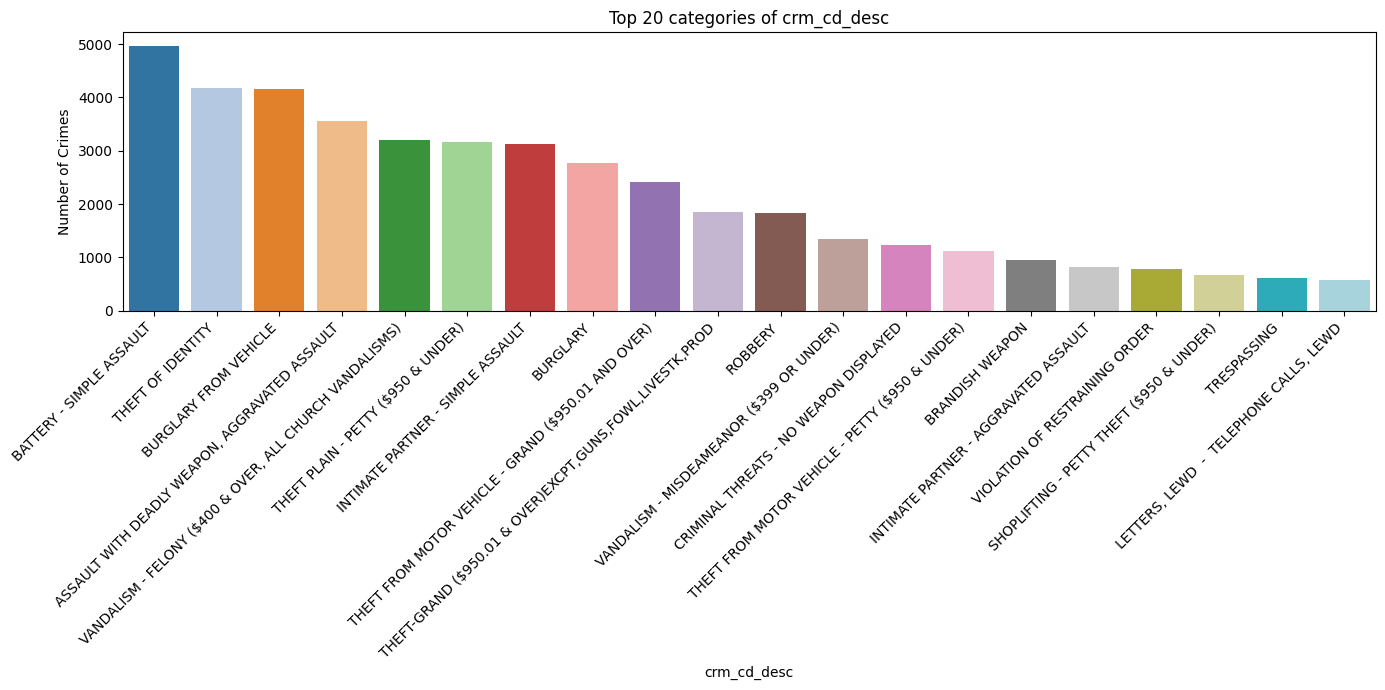

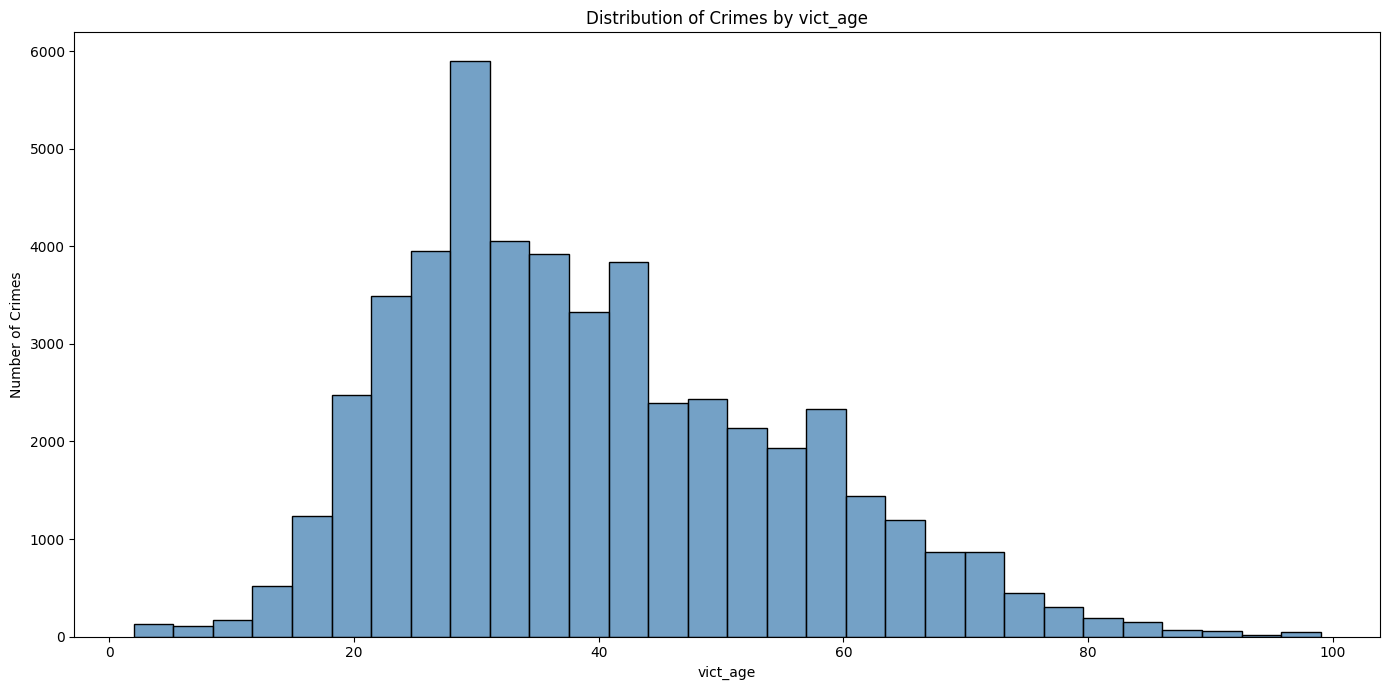

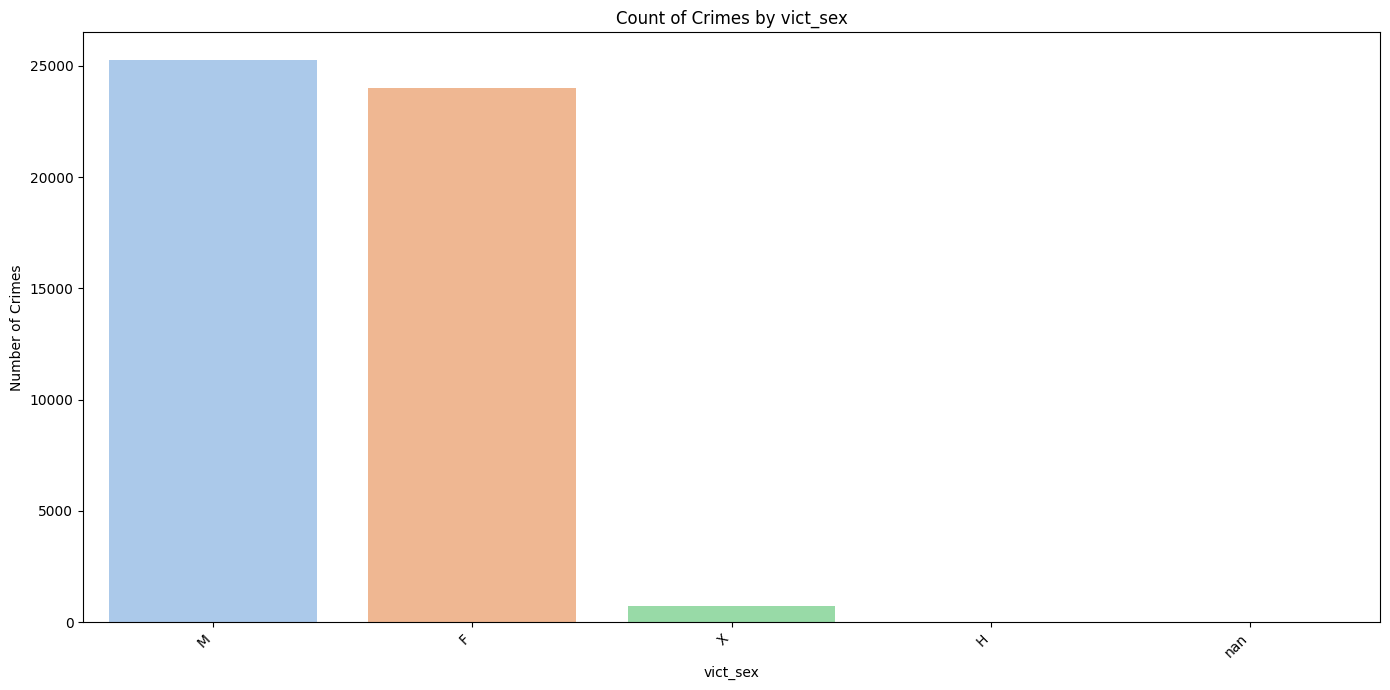

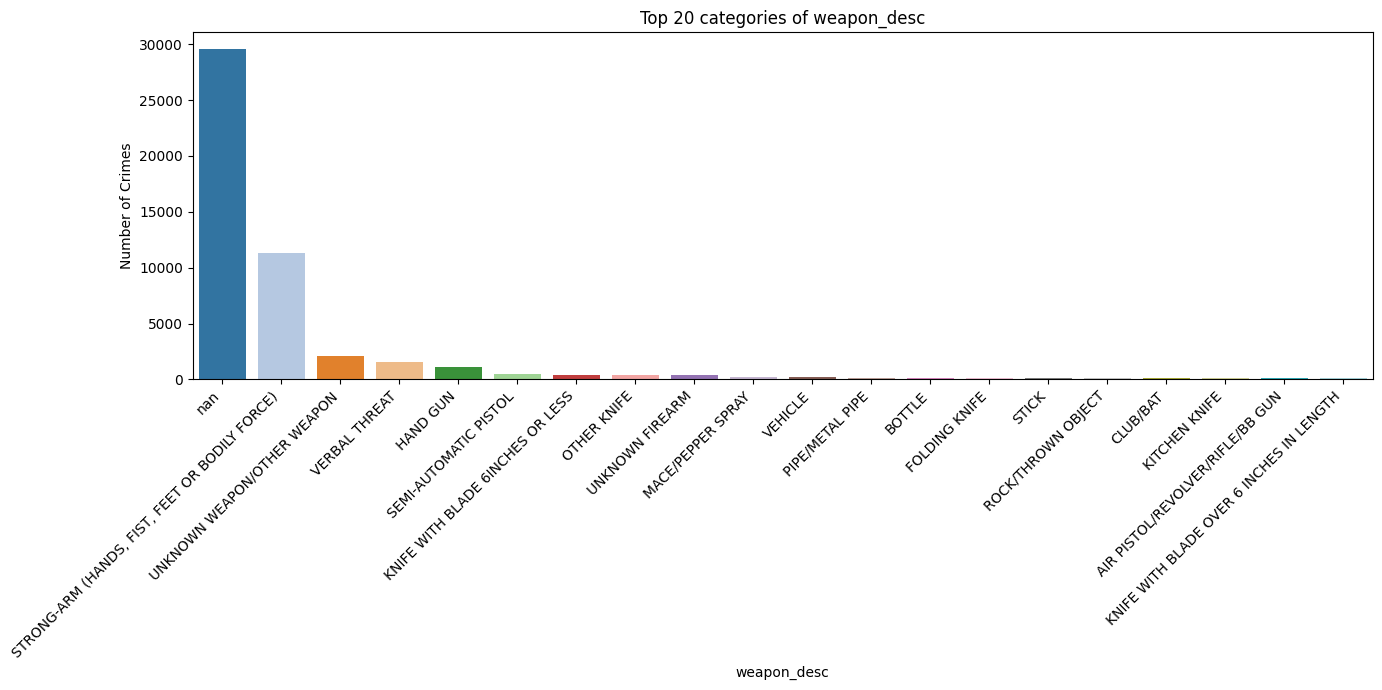

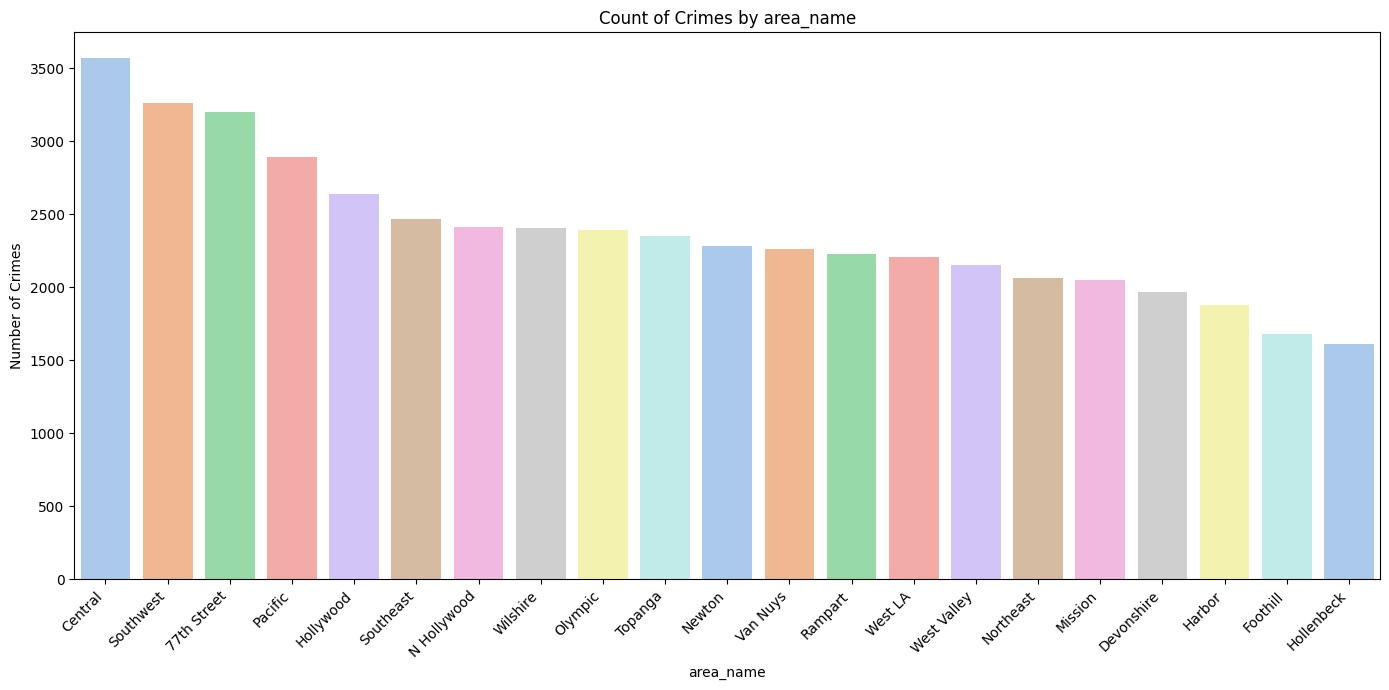

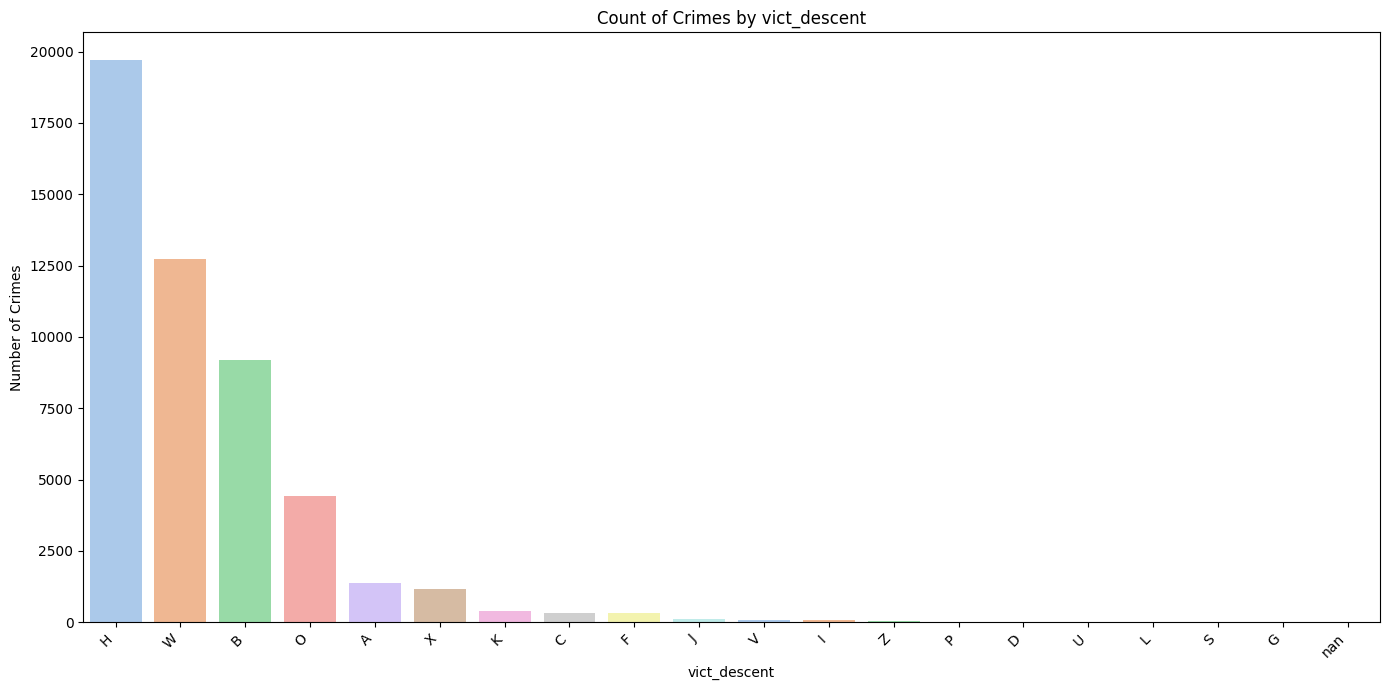

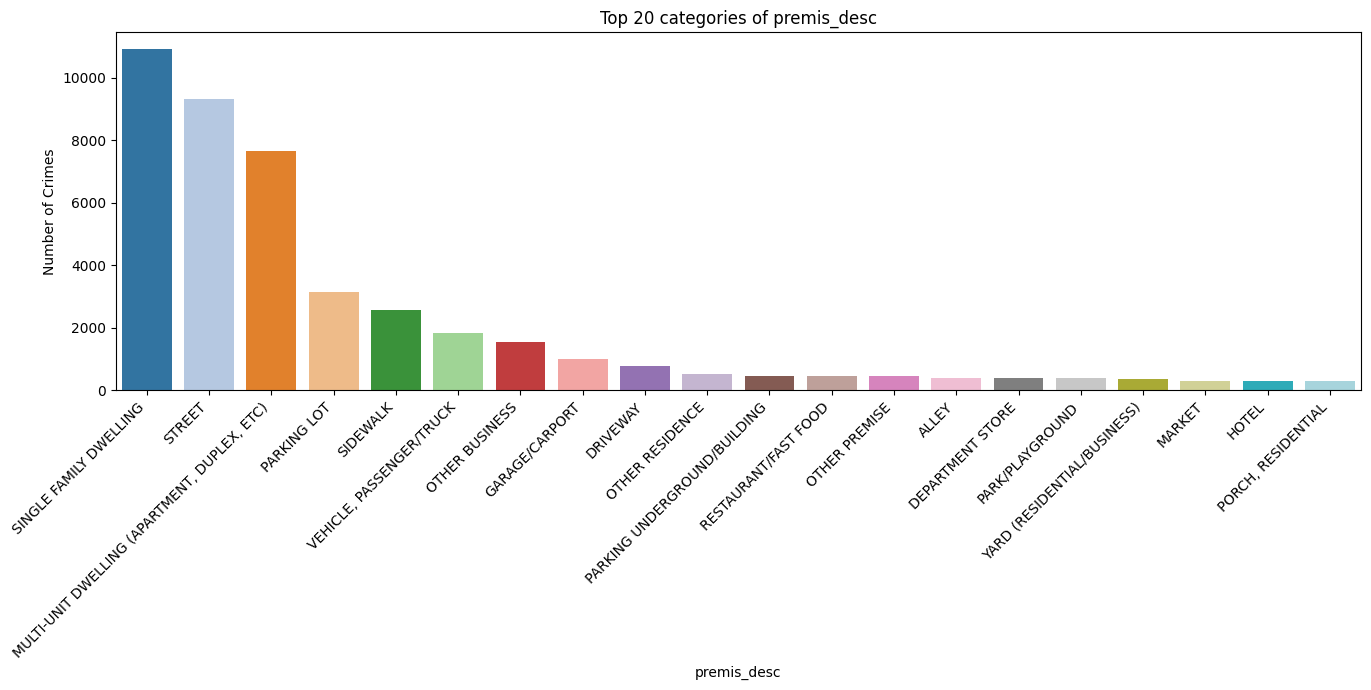

Histograms generated successfully.

==== Generating Crimes per Hour Bar Chart ====


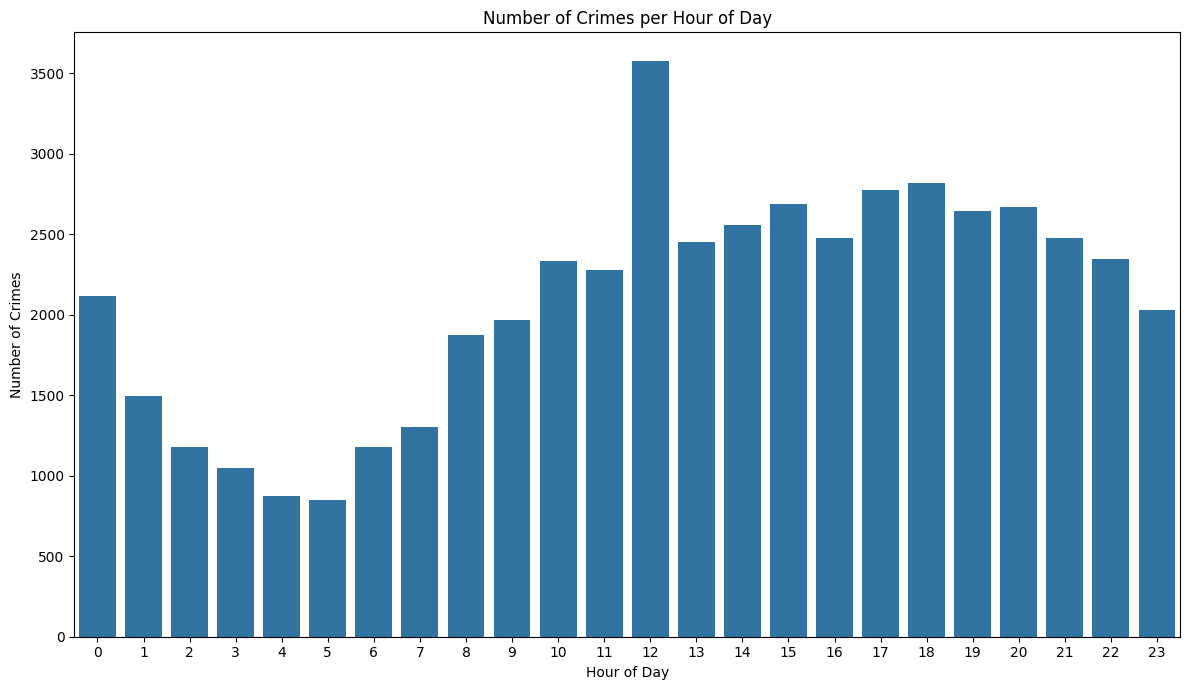


==== Generating Heatmap: Crime Count by Hour and Day of Week ====


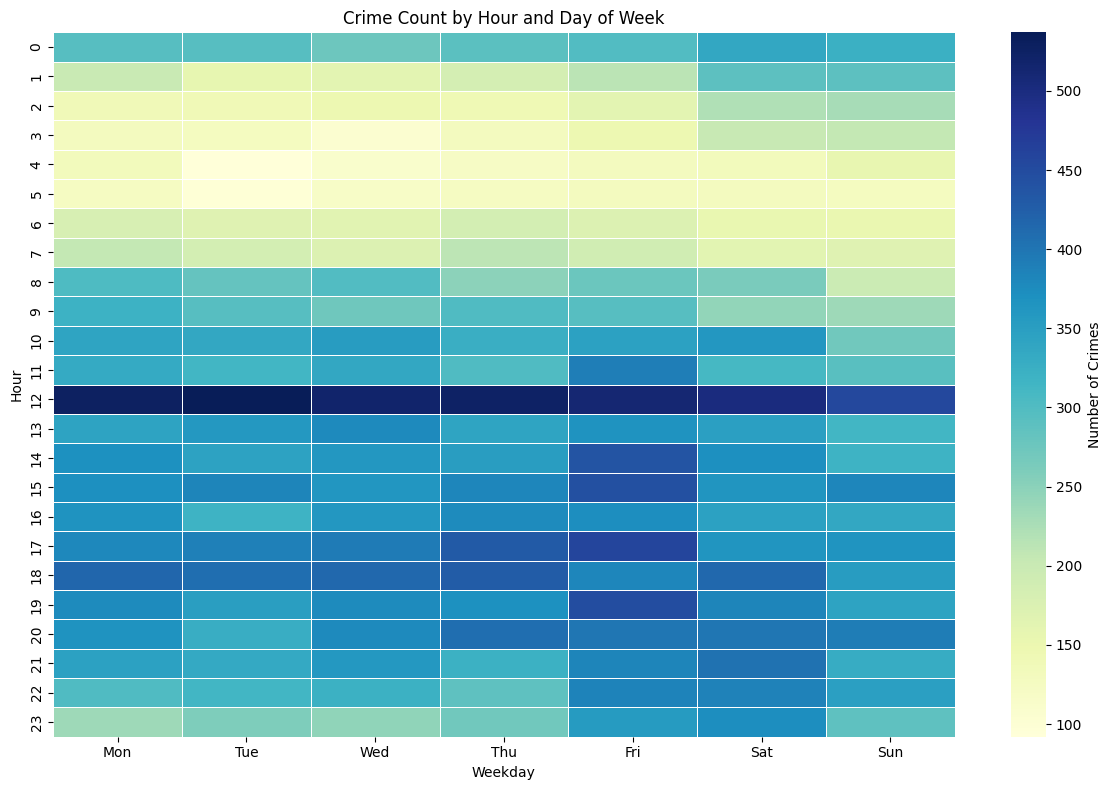

Heatmap generated successfully.

==== Generating Heatmap: Crime Count by Month and Year ====


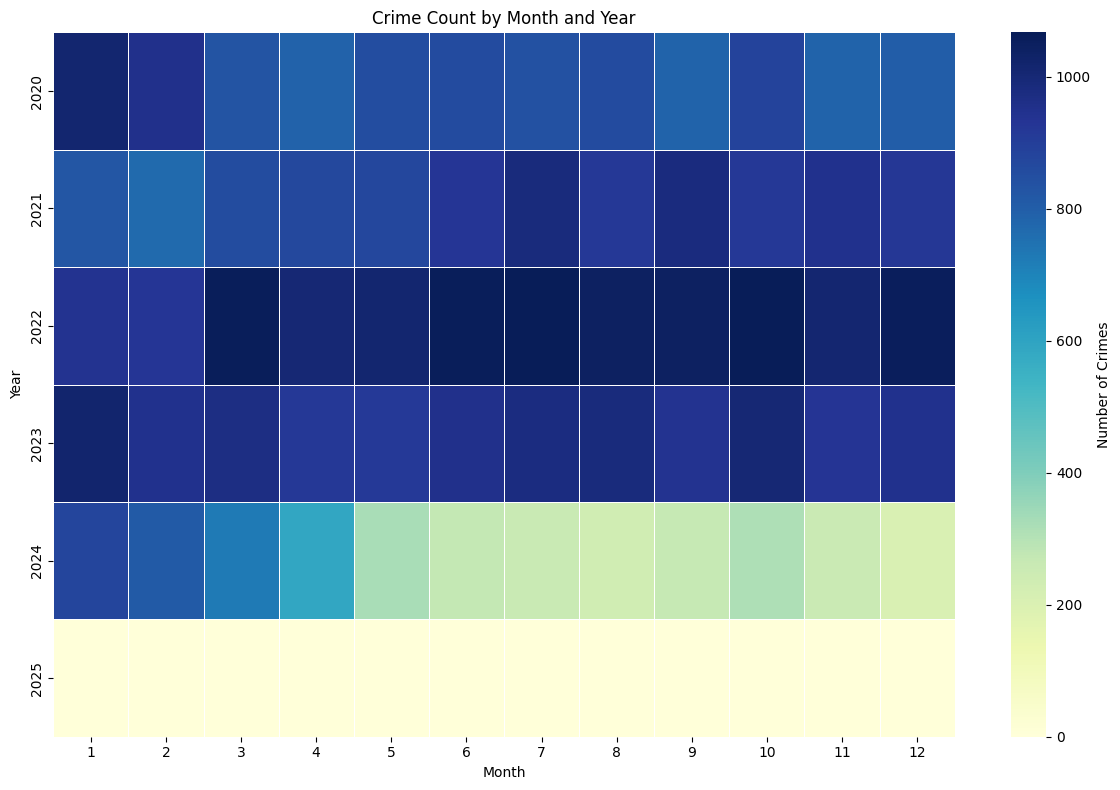

Heatmap generated successfully.

==== Generating Day vs. Night Pie Chart ====


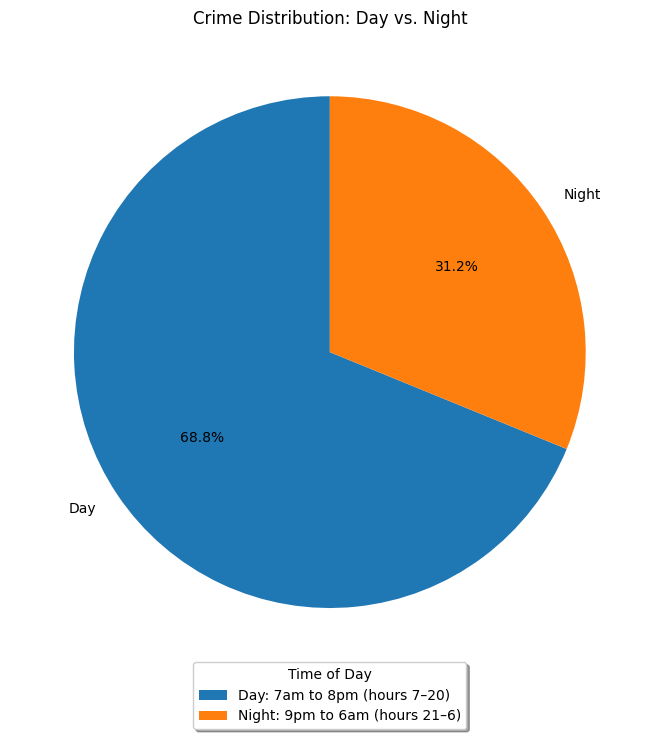

Pie chart generated successfully.

==== Generating Correlation Heatmap ====


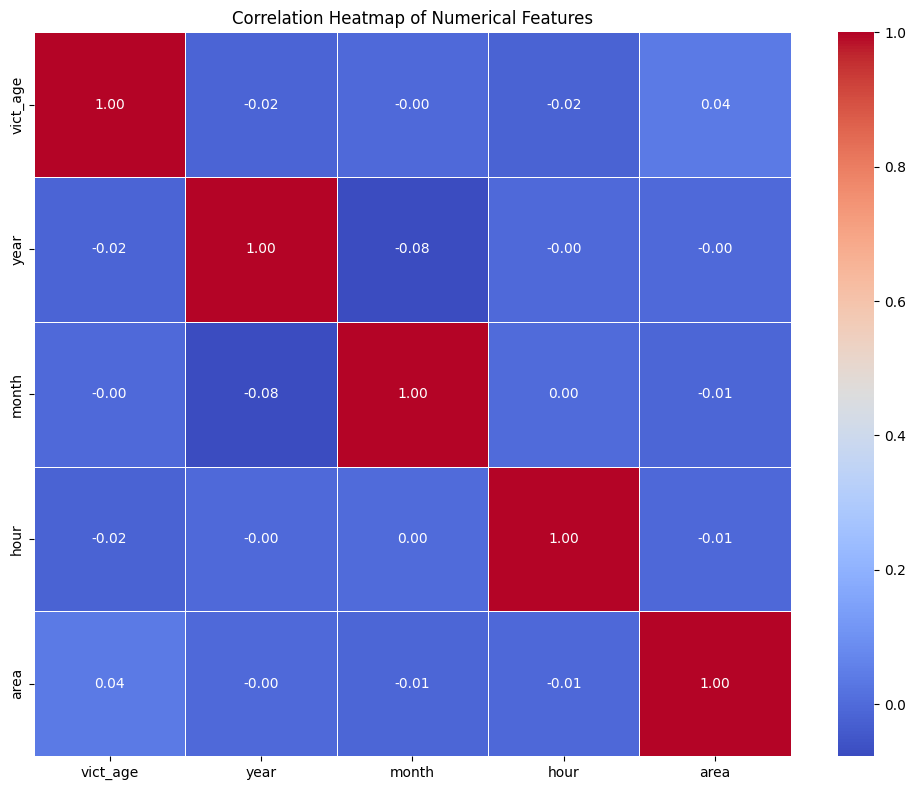

Correlation heatmap generated successfully.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from typing import Dict, Any

warnings.filterwarnings("ignore")

# --- Configuration ---
RAW_PATH = "https://data.lacity.org/api/views/2nrs-mtv8/rows.csv?accessType=DOWNLOAD"
OUTPUT_DIR = "/content/plots"
SAMPLE_N = 50000
MISSING = ["", " ", "NA", "N/A", "None", "null", "?", "-"]
RANDOM_SEED = 42
TOP_N_CATS = 20  # how many top categories to show for large categorical features

# --- Helper Functions ---
def _ensure_dirs(*dirs):
    """Ensures that the given directories exist."""
    for d in dirs:
        if not os.path.exists(d):
            os.makedirs(d)

def create_time_features(df: pd.DataFrame) -> pd.DataFrame:
    """Creates time-related features from the 'DATE OCC' and 'TIME OCC' columns."""
    df = df.copy()
    df.columns = df.columns.str.lower().str.replace(' ', '_', regex=False)

    if 'date_occ' in df.columns:
        df['date_occ'] = pd.to_datetime(df['date_occ'], errors='coerce')
        df['year'] = df['date_occ'].dt.year
        df['month'] = df['date_occ'].dt.month
        df['weekday'] = df['date_occ'].dt.day_of_week

    if 'time_occ' in df.columns:
        df['time_str'] = (
            df['time_occ']
            .astype(str)
            .str.replace(r'[^0-9]', '', regex=True)
            .str.zfill(4)
        )
        df['hour'] = pd.to_numeric(df['time_str'].str[:2], errors='coerce')
        df = df.dropna(subset=['hour'])
        df['hour'] = df['hour'].astype(int)

    return df

def create_night_target(df: pd.DataFrame) -> pd.DataFrame:
    """Creates a binary target 'is_night' based on the hour."""
    df = df.copy()
    if 'hour' in df.columns:
        df['is_night'] = ((df['hour'] >= 21) | (df['hour'] <= 6)).astype(int)
    return df

def plot_histograms_for_features(df: pd.DataFrame, features, output_dir: str):
    _ensure_dirs(output_dir)
    print("\n==== Generating Histograms ====")

    exclude_list = {'dr_no', 'rpt_dist_no', 'mocodes', 'cross_street', 'address', 'lat', 'lon'}

    for feature in features:
        if feature in exclude_list or feature not in df.columns:
            continue

        plt.figure(figsize=(14, 7))
        is_numeric = pd.api.types.is_numeric_dtype(df[feature])
        n_unique = df[feature].nunique(dropna=True)

        if not is_numeric:
            if n_unique > 50:
                vc = df[feature].astype(str).value_counts().nlargest(TOP_N_CATS)
                palette = sns.color_palette("tab20", n_colors=len(vc))
                sns.barplot(x=vc.index, y=vc.values, palette=palette)
                plt.title(f"Top {TOP_N_CATS} categories of {feature}")
                plt.xticks(rotation=45, ha='right')
            else:
                vc = df[feature].astype(str).value_counts()
                palette = sns.color_palette("pastel", n_colors=len(vc))
                sns.barplot(x=vc.index, y=vc.values, palette=palette)
                plt.title(f"Count of Crimes by {feature}")
                plt.xticks(rotation=45, ha='right')
        else:
            sns.histplot(data=df, x=feature, bins=30, color="steelblue", edgecolor="black")
            plt.title(f"Distribution of Crimes by {feature}")

        plt.xlabel(feature)
        plt.ylabel("Number of Crimes")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f"histogram_{feature}.png"))
        plt.show()
        plt.close()

    print("Histograms generated successfully.")

def plot_crime_heatmap(df: pd.DataFrame, x_col: str, y_col: str, output_dir: str, title: str):
    """Generates and saves a heatmap for crime counts between two variables."""
    print(f"\n==== Generating Heatmap: {title} ====")
    plt.figure(figsize=(12, 8))

    heatmap_data = df.groupby([y_col, x_col]).size().unstack(fill_value=0)

    if y_col == 'hour':
        heatmap_data = heatmap_data.sort_index()
    if x_col == 'weekday':
        weekday_order = list(range(7))
        heatmap_data = heatmap_data.reindex(columns=weekday_order)
        x_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    else:
        x_labels = heatmap_data.columns

    sns.heatmap(heatmap_data, cmap="YlGnBu", linewidths=.5, cbar_kws={'label': 'Number of Crimes'})

    plt.title(title)
    plt.xlabel(x_col.replace('_', ' ').title())
    plt.ylabel(y_col.replace('_', ' ').title())

    if x_col == 'weekday':
        plt.xticks(ticks=np.arange(len(x_labels)) + 0.5, labels=x_labels)

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"heatmap_{y_col}_vs_{x_col}.png"))
    plt.show()
    plt.close()
    print("Heatmap generated successfully.")

def _plot_night_day_pie_chart(df: pd.DataFrame, output_dir: str):
    """Plots a pie chart for the distribution of day vs. night crimes."""
    _ensure_dirs(output_dir)
    print("\n==== Generating Day vs. Night Pie Chart ====")

    night_counts = df['is_night'].value_counts()
    labels = ['Day', 'Night']
    sizes = [night_counts.get(0, 0), night_counts.get(1, 0)]

    plt.figure(figsize=(8, 8))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)

    legend_labels = [
        'Day: 7am to 8pm (hours 7–20)',
        'Night: 9pm to 6am (hours 21–6)'
    ]
    plt.legend(legend_labels, loc='lower center', bbox_to_anchor=(0.5, -0.1),
               title="Time of Day", fancybox=True, shadow=True)

    plt.title('Crime Distribution: Day vs. Night')
    plt.ylabel('')
    plt.tight_layout(pad=3.0)
    plt.savefig(os.path.join(output_dir, "day_night_pie_chart.png"))
    plt.show()
    plt.close()
    print("Pie chart generated successfully.")

def _plot_correlation_heatmap(df: pd.DataFrame, output_dir: str):
    """Plots a correlation heatmap for key numerical features."""
    _ensure_dirs(output_dir)
    print("\n==== Generating Correlation Heatmap ====")

    numerical_features = ['vict_age', 'year', 'month', 'hour', 'area']
    cols_to_corr = [
        col for col in numerical_features
        if col in df.columns and pd.api.types.is_numeric_dtype(df[col])
    ]

    if not cols_to_corr:
        print("No numerical columns found to create a correlation heatmap.")
        return

    corr_matrix = df[cols_to_corr].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Correlation Heatmap of Numerical Features')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "correlation_heatmap.png"))
    plt.show()
    plt.close()
    print("Correlation heatmap generated successfully.")

# --- Main Script ---
def main():
    print("=== LAPD EDA – All Graphs ===")

    print("Loading data...")
    try:
        df = pd.read_csv(RAW_PATH, low_memory=False)
    except Exception as e:
        print(f"Error loading data from the URL. Error: {e}")
        return

    print("Cleaning and preparing data...")
    df = df.replace(MISSING, np.nan)
    df.columns = df.columns.str.lower().str.replace(' ', '_')

    # Remove invalid victim ages
    if 'vict_age' in df.columns:
        df['vict_age'] = pd.to_numeric(df['vict_age'], errors='coerce')
        df = df[df['vict_age'] > 0]
        df = df.dropna(subset=['vict_age'])
        print(f"Filtered out rows with vict_age == 0 or missing. New size: {len(df):,}")

    # Sample AFTER cleaning
    if len(df) > SAMPLE_N:
        df = df.sample(SAMPLE_N, random_state=RANDOM_SEED)
    print(f"Working shape: {df.shape}")

    # Time features + target
    df_clean = create_time_features(df)
    df_clean = create_night_target(df_clean)

    print("\n==== Generating All Plots ====")
    features_to_plot = [
        'crm_cd_desc', 'vict_age', 'vict_sex',
        'weapon_desc', 'area_name', 'vict_descent', 'premis_desc'
    ]
    plot_histograms_for_features(df_clean, features_to_plot, OUTPUT_DIR)

    # Crimes per hour bar chart
    print("\n==== Generating Crimes per Hour Bar Chart ====")
    plt.figure(figsize=(12, 7))
    sns.countplot(x='hour', data=df_clean)
    plt.title('Number of Crimes per Hour of Day')
    plt.xlabel('Hour of Day')
    plt.ylabel('Number of Crimes')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "crimes_per_hour_bar_chart.png"))
    plt.show()
    plt.close()

    # Heatmaps
    plot_crime_heatmap(df_clean, 'weekday', 'hour', OUTPUT_DIR,
                       "Crime Count by Hour and Day of Week")
    plot_crime_heatmap(df_clean, 'month', 'year', OUTPUT_DIR,
                       "Crime Count by Month and Year")

    # Additional graphs
    _plot_night_day_pie_chart(df_clean, OUTPUT_DIR)
    _plot_correlation_heatmap(df_clean, OUTPUT_DIR)

if __name__ == "__main__":
    main()


In [ ]:
# --- Extra diagnostic block: classify columns by unique counts ---
try:
    # Re-load and clean the dataframe the same way main() does
    df_extra = pd.read_csv(RAW_PATH, low_memory=False)
    df_extra = df_extra.replace(MISSING, np.nan)
    df_extra.columns = df_extra.columns.str.lower().str.replace(' ', '_')

    if 'vict_age' in df_extra.columns:
        df_extra['vict_age'] = pd.to_numeric(df_extra['vict_age'], errors='coerce')
        df_extra = df_extra[df_extra['vict_age'] > 0]
        df_extra = df_extra.dropna(subset=['vict_age'])

    if len(df_extra) > SAMPLE_N:
        df_extra = df_extra.sample(SAMPLE_N, random_state=RANDOM_SEED)

    print("\n==== Column Type Classification (unique-count rule) ====")
    col_types = {}
    for col in df_extra.columns:
        n_unique = df_extra[col].nunique(dropna=True)
        if n_unique > 25:
            col_types[col] = "numeric"
        else:
            col_types[col] = "categorical"
        print(f"{col:20} → {col_types[col]} (unique values: {n_unique})")

except Exception as e:
    print(f"Error in extra diagnostic block: {e}")



==== Column Type Classification (unique-count rule) ====
dr_no                → numeric (unique values: 50000)
date_rptd            → numeric (unique values: 1834)
date_occ             → numeric (unique values: 1827)
time_occ             → numeric (unique values: 1388)
area                 → categorical (unique values: 21)
area_name            → categorical (unique values: 21)
rpt_dist_no          → numeric (unique values: 1137)
part_1-2             → categorical (unique values: 2)
crm_cd               → numeric (unique values: 114)
crm_cd_desc          → numeric (unique values: 114)
mocodes              → numeric (unique values: 25626)
vict_age             → numeric (unique values: 98)
vict_sex             → categorical (unique values: 4)
vict_descent         → categorical (unique values: 19)
premis_cd            → numeric (unique values: 265)
premis_desc          → numeric (unique values: 263)
weapon_used_cd       → numeric (unique values: 70)
weapon_desc          → numeric (unique 

In [ ]:
# --- Extra block: One-Hot Encode all categorical columns ---
try:
    # Use df_extra from the previous block if it exists
    if "df_extra" not in locals():
        df_extra = pd.read_csv(RAW_PATH, low_memory=False)
        df_extra = df_extra.replace(MISSING, np.nan)
        df_extra.columns = df_extra.columns.str.lower().str.replace(' ', '_')
        if 'vict_age' in df_extra.columns:
            df_extra['vict_age'] = pd.to_numeric(df_extra['vict_age'], errors='coerce')
            df_extra = df_extra[df_extra['vict_age'] > 0]
            df_extra = df_extra.dropna(subset=['vict_age'])
        if len(df_extra) > SAMPLE_N:
            df_extra = df_extra.sample(SAMPLE_N, random_state=RANDOM_SEED)

    # Step 1: detect categorical columns (<= 25 unique values)
    cat_cols = [col for col in df_extra.columns if df_extra[col].nunique(dropna=True) <= 25]

    print("\nOne-Hot Encoding Categorical Columns")
    print("Categorical columns selected:", cat_cols)

    # Step 2: apply one-hot encoding
    df_encoded = pd.get_dummies(df_extra, columns=cat_cols, drop_first=False)

    print(f"Original shape: {df_extra.shape}")
    print(f"Encoded shape:  {df_encoded.shape}")
    print("Preview of encoded DataFrame:")
    print(df_encoded.head())

except Exception as e:
    print(f"Error in one-hot encoding block: {e}")


One-Hot Encoding Categorical Columns
Categorical columns selected: ['area', 'area_name', 'part_1-2', 'vict_sex', 'vict_descent', 'status', 'status_desc', 'crm_cd_3', 'crm_cd_4']
Original shape: (50000, 28)
Encoded shape:  (50000, 111)
Preview of encoded DataFrame:
            dr_no               date_rptd                date_occ  time_occ  \
141837  200218998  12/25/2020 12:00:00 AM  12/25/2020 12:00:00 AM      1730   
197526  201309386  04/14/2020 12:00:00 AM  04/12/2020 12:00:00 AM      1450   
548811  221306294  02/14/2022 12:00:00 AM  02/13/2022 12:00:00 AM       158   
244562  212018691  12/24/2021 12:00:00 AM  12/24/2021 12:00:00 AM       130   
450725  240907146  03/23/2024 12:00:00 AM  10/23/2022 12:00:00 AM       210   

        rpt_dist_no  crm_cd                                     crm_cd_desc  \
141837          289     230  ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT   
197526         1343     761                                 BRANDISH WEAPON   
548811         1352   